# Workflow Test: Vacuum Gripper
### Geometries, Gripper, Grasp Sampler

In [1]:
import os
from os.path import join as pjoin
import sys
import numpy as np
import open3d as o3d
import yaml
from copy import deepcopy

# Import our custom modules
# from src.grippers.vacuum_gripper import VacuumGripper, VacuumGripperConfig
from src.grippers.vacuum_gripper_v2 import VacuumGripper, VacuumGripperConfig
# from src.grasping.vacuum_sampler import VacuumGraspSampler, VacuumSamplerConfig
from src.grasping.vacuum_sampler_v2 import VacuumGraspSampler, VacuumSamplerConfig
import src.utils.geometry_utils as gu
from src.generic_geometry import GenericGeometry


### Load Configs and data

In [24]:
# franka_path = pjoin("gripper_parameter", "double_quad_cup.yaml")
# franka_path = pjoin("gripper_parameter", "double_quad_cup_2.yaml")
# franka_path = pjoin("gripper_parameter", "double_cup.yaml")
# franka_path = pjoin("gripper_parameter", "single_circle_cup_1cm_diam.yaml")
# franka_path = pjoin("gripper_parameter", "single_circle_cup_2cm_diam.yaml")
franka_path = pjoin("gripper_parameter", "double_cup_1cm_1cm.yaml")
# franka_path = pjoin("gripper_parameter", "quadruple_cup_1cm_1cm.yaml")
# franka_path = pjoin("gripper_parameter", "franka_vacuum.yaml")

# object_path = pjoin("Test_part", "pringles", "clouds","merged_cloud.ply")
# object_path = pjoin("Test_part","Verification_examples","combined.ply")
# object_path = r"Test_part/cracker_box/clouds/merged_cloud.ply"

# VULKAN FILES
# object_path = r"Test_part/Vulkan/stl/Vulkan complete assembly.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan M12 Nut.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan Nesting AM.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan part 1.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan part 2.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan part 3.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan part 4-Body.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan part 5.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan part 6.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan part assembly.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan screw.stl"
# object_path = r"Test_part/Vulkan/stl/Vulkan subassembly JMS paper.stl"
object_path = r"Test_part/Vulkan/stl/Subassembly.ply"
gripper = VacuumGripper(franka_path)
pcd = GenericGeometry(object_path)
# pcd.estimate_normals()

✅ Geometry set: mesh (open3d)
Applying rigid transformation...
🔧 Vacuum Gripper 'Double_Schmalz_ECG' initialized.
   - Active Pads: 2
[Open3D WARNING] geometry::TriangleMesh appears to be a geometry::PointCloud (only contains vertices, but no triangles).
[Open3D] Loaded PointCloud: Test_part/Vulkan/stl/Subassembly.ply
✅ Geometry set: point_cloud (open3d)


In [26]:
gripper.visualize()

In [4]:
pcd.visualize()

In [5]:
o3d.visualization.draw_geometries([gripper.collision_geometry.geometry, pcd.geometry], point_show_normal=True)

## Create Grasp Sampler

In [6]:
# 2. Initialize Sampler Configuration
config_path = pjoin("config", "config.yaml")
with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

# sampler_config = VacuumSamplerConfig(
#     num_samples=1200,        # Cast 300 rays
#     approach_distance=0.15, # 15cm approach check
#     local_clearence_margin=0.02,
#     safety_volume_shape= "bounding_box_shape",
#     max_angle_deg=45,
#     min_score=0.1,           # Minimum GSS to accept
#     # rotation_strategy='uniform', # 'uniform' or 'fixed'
#     rotation_strategy='uniform', # 'uniform' or 'fixed'
#     rotation_step_deg=10,
#     rotation_range_deg=180,
#     score_aggregation_method="median",
#     debug_score=True

# )

sampler_config = VacuumSamplerConfig(**config)
# 3. Initialize Sampler
sampler = VacuumGraspSampler(gripper, sampler_config)

[VacuumSampler] Using Contact Strategy: projection


### Downsample and Clean

In [7]:
dim_report = pcd.get_dimensions_report()
print("Object dimensions report:")
for k,v in dim_report.items():
    print(f"  {k}: {v}")

Object dimensions report:
  extents_xyz: [0.0699 0.1015 0.073 ]
  diagonal: 0.1432
  likely_unit: meters
  suggested_voxel_size: 0.00143
  details: Type: Open3D PointCloud. Size: 0.07 x 0.10 x 0.07. Unit: METERS.


### Convert to Meters

In [7]:
pcd.scale(0.001)

In [9]:
dim_report = pcd.get_dimensions_report()
print("Object dimensions report:")
for k,v in dim_report.items():
    print(f"  {k}: {v}")

Object dimensions report:
  extents_xyz: [0.0699 0.1015 0.073 ]
  diagonal: 0.1432
  likely_unit: meters
  suggested_voxel_size: 0.00143
  details: Type: Open3D PointCloud. Size: 0.07 x 0.10 x 0.07. Unit: METERS.


In [7]:
# GenericGeometry(geometry=gripper.generate_safety_collision_mesh(
#     np.array([0,0,0]),
#     np.array([0,0,1]),
#     0.2
# )).visualize()

In [8]:
voxel_size = 0.001
pcd_down = pcd.downsample(voxel_size=voxel_size)
pcd_down = GenericGeometry(geometry=pcd_down)
pcd_down.visualize()

Downsampling with voxel_size=0.001...
✅ Geometry set: point_cloud (open3d)


In [8]:
# pcd_down.clean_point_cloud(inplace=True)
# pcd_down.remove_outliers_physical(inplace=True, min_neighbors=5)
# pcd_down.visualize()

In [9]:
pcd_down_aligned_list = gu.align_largest_plane_to_z(pcd_down.geometry, 1.0*voxel_size, k=3, theta_min_diff=30)
# pcd_down = GenericGeometry(geometry=pcd_down)
# pcd_down.visualize()

In [10]:
for _pcd in pcd_down_aligned_list:
    GenericGeometry(geometry=_pcd).visualize()

✅ Geometry set: point_cloud (open3d)
✅ Geometry set: point_cloud (open3d)
✅ Geometry set: point_cloud (open3d)


### Sample Grasps

In [21]:
# # Run the sampling pipeline
# # pcd_down = pcd.downsample(voxel_size=0.003)
# grasps = sampler.sample_grasps(pcd_down_aligned_list[2])

# print(f"\nResult: Found {len(grasps)} valid grasps.")

# if len(grasps) > 0:
#     best_grasp = grasps[0]
#     print(f"Top Grasp Score: {best_grasp.score:.4f}")
#     print(f"Top Grasp Position: {best_grasp.contact_point}")
# else:
#     print("No valid grasps found. Check thresholds.")

[Debug] Visualizing Raycasting Mesh (Type: poisson)...
[Debug] Abrindo Visualizador de Raycasting (poisson)...
[VacuumSampler] Phase 1: Generated 410 candidates.
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 3 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 0 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 0 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 2 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 0 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 2 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 0 | Spacing: 0.0013
[Debug Seali

In [25]:
# Run the sampling pipeline
# pcd_down = pcd.downsample(voxel_size=0.003)
sampler_grasps_tuples = []
for _pcd_down in pcd_down_aligned_list:
    _sampler = VacuumGraspSampler(gripper, sampler_config)
    # _sampler = deepcopy(sampler)
    grasps = _sampler.sample_grasps(_pcd_down)
    sampler_grasps_tuples.append((_sampler, deepcopy(grasps)))
print(f"\nResult: Found {len(grasps)} valid grasps.")

for _sampler, grasps in sampler_grasps_tuples:
    if len(grasps) > 0:
        best_grasp = grasps[0]
        print(f"Top Grasp Score: {best_grasp.score:.4f}")
        print(f"Top Grasp Position: {best_grasp.contact_point}")
    else:
        print("No valid grasps found. Check thresholds.")

[VacuumSampler] Using Contact Strategy: projection
[Debug] Visualizing Raycasting Mesh (Type: poisson)...
[Debug] Abrindo Visualizador de Raycasting (poisson)...
[VacuumSampler] Phase 1: Generated 121 candidates.
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 2 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 2 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 2 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 2 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 1 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 0 | Spacing: 0.0013
[Debug Sealing] Expected: 2.2 | Valid: 0 | Spacing: 0.0013
[Debug Sealing] Expe

In [22]:
# # for c in sampler.get_best_candidates(8):
# for c in [best_grasp]:
# # for c in [sampler.candidates[50]]:
#     sampler.visualize_grasp(pcd_down_aligned_list[2], c)
#     # sampler.visualize_grasp(pcd_down.geometry, c)

✅ Geometry set: mesh (open3d)
Applying rigid transformation...


In [13]:
# for c in sampler.get_best_candidates(8):
for i, (s,g) in enumerate(sampler_grasps_tuples):
# for c in [sampler.candidates[50]]:
    if len(g) > 0:
        s.visualize_grasp(pcd_down_aligned_list[i], g[0])
    # sampler.visualize_grasp(pcd_down.geometry, c)

In [21]:
selected_dir = 2

In [ ]:
best_grasp = sampler_grasps_tuples[selected_dir][1][0]
best_grasp.score_details

In [22]:
_sampler, _grasps = sampler_grasps_tuples[selected_dir]
_pcd_down = pcd_down_aligned_list[selected_dir]

<Axes: ylabel='Count'>

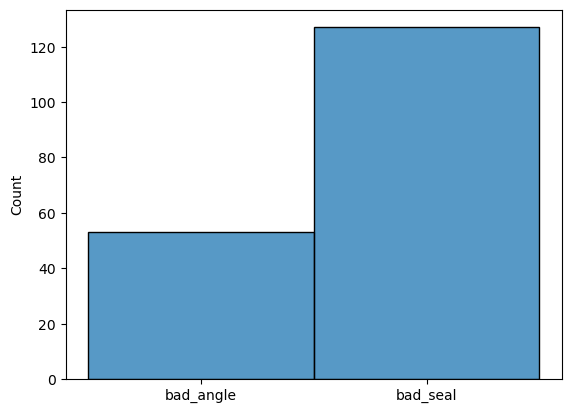

In [19]:
import seaborn as sns
reasons = [c.score_details.get("failure_reason", []) for c in _sampler.candidates]
reasons = sum(reasons, start=[])
sns.histplot(reasons)

In [23]:

# # for c in sampler.get_best_candidates(8):
for c in _sampler.valid_candidates[:20]:
# for c in [*sampler.candidates[:50]]:
    sampler.visualize_grasp(_pcd_down, c)

(array([482.,   0.,  29.,   0.,   0.,  59.,   0., 119.,   0.,   0., 123.,
          0.,  52.,   0.,   0.,  22.,   0.,  24.,   0., 222.]),
 array([0.  , 0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 ,
        0.55, 0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  ]),
 <BarContainer object of 20 artists>)

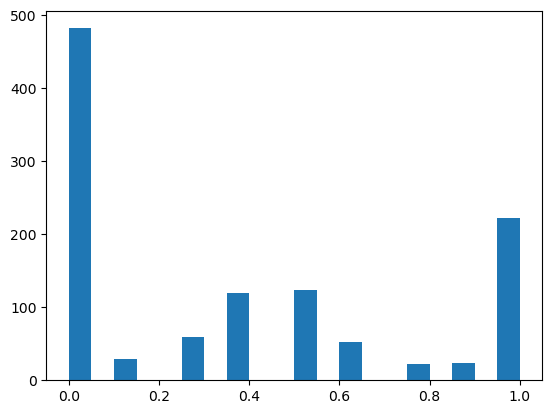

In [14]:
import matplotlib.pyplot as plt
plt.hist(list(map(lambda c: c.score_details.get("seal_score") , sampler.candidates)), bins=20)

In [20]:
sampler.visualize_candidates_heatmap(pcd_down.geometry, valid_only=False, relative_scale=False)

In [86]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,
                                     attribute='verticality',
                                     valid_only=False,
                                     relative_scale=False)

In [56]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,attribute='torque', valid_only=False, )

In [105]:
sampler.visualize_candidates_heatmap(pcd_down.geometry,attribute='seal_score', valid_only=False)

In [27]:
GenericGeometry(geometry=pcd_down_aligned_list[0]).visualize()

✅ Geometry set: point_cloud (open3d)


In [31]:
_sampler.visualize_candidates_heatmap(_pcd_down, valid_only=False, relative_scale=False)

In [52]:
_sampler.visualize_candidates_heatmap(_pcd_down,
                                     attribute='verticality',
                                     valid_only=False,
                                     relative_scale=False)

In [53]:
_sampler.visualize_candidates_heatmap(_pcd_down,attribute='torque', valid_only=False, )

In [54]:
_sampler.visualize_candidates_heatmap(_pcd_down,attribute='seal_score', valid_only=False)

In [64]:
sampler_grasps_tuples[0][1][0]

GraspCandidate(transform=array([[ 9.99968152e-01,  6.17981878e-05, -7.98068379e-03,
        -2.30347095e-02],
       [ 6.17981878e-05,  9.99880086e-01,  1.54857654e-02,
         1.16305266e-02],
       [ 7.98068379e-03, -1.54857654e-02,  9.99848238e-01,
         3.16249967e-02],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         1.00000000e+00]]), score=np.float64(0.6254379089866777), contact_point=array([-0.02303471,  0.01163053,  0.031625  ]), approach_vector=array([ 0.00798055, -0.01548551, -0.99983175]), score_details={'seal_score': np.float64(0.22425146871035412), 'verticality': np.float64(0.976643422714075), 'torque': np.float64(0.8838981385311634), 'raw_angle_deg': np.float64(1.0510459778666252), 'pad_scores': {'left_cup': np.float64(0.22425146871035412)}, 'failure_reason': []})